<a href="https://colab.research.google.com/github/meheramey/assignment_03_bitsom_ba_2511968_Part4/blob/main/part4_visualization_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 4: Data Visualization & Machine Learning
### Theme: Student Performance Analysis & Prediction

In [1]:
# importing all libraries we need for this assignment
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

## Task 1 — Data Exploration with Pandas

In [2]:
# load the csv file into a dataframe
df = pd.read_csv('students.csv')

# print first 5 rows to see what data looks like
print('=== First 5 rows ===')
print(df.head())

=== First 5 rows ===
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  


In [3]:
# shape tells us rows x columns, dtypes tells us the data type of each column
print('=== Shape (rows x columns) ===')
print(df.shape)

print('\n=== Data types of each column ===')
print(df.dtypes)

=== Shape (rows x columns) ===
(15, 9)

=== Data types of each column ===
name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object


In [4]:
# describe() gives mean, min, max, std for all numeric columns automatically
print('=== Summary Statistics ===')
print(df.describe())

=== Summary Statistics ===
            math    science    english    history         pe  attendance_pct  \
count  15.000000  15.000000  15.000000  15.000000  15.000000       15.000000   
mean   65.000000  66.733333  66.200000  63.400000  74.800000       75.800000   
std    20.060622  18.967893  17.773174  16.936014  16.657045       14.722189   
min    30.000000  35.000000  40.000000  28.000000  45.000000       50.000000   
25%    51.500000  53.500000  49.000000  53.500000  61.000000       63.500000   
50%    65.000000  65.000000  70.000000  62.000000  75.000000       78.000000   
75%    80.000000  77.000000  81.000000  73.500000  89.000000       86.500000   
max    95.000000  98.000000  91.000000  92.000000  97.000000       98.000000   

       study_hours_per_day     passed  
count            15.000000  15.000000  
mean              2.893333   0.600000  
std               1.658944   0.507093  
min               0.500000   0.000000  
25%               1.650000   0.000000  
50%         

In [5]:
# count how many students passed (1) and how many failed (0)
print('=== Pass / Fail Count ===')
print(df['passed'].value_counts())

=== Pass / Fail Count ===
passed
1    9
0    6
Name: count, dtype: int64


In [6]:
# subject columns list - will reuse this many times below
subject_cols = ['math', 'science', 'english', 'history', 'pe']

# filter rows where passed==1 then take mean of subject columns
pass_avg = df[df['passed'] == 1][subject_cols].mean()

# filter rows where passed==0 then take mean of subject columns
fail_avg = df[df['passed'] == 0][subject_cols].mean()

print('=== Average score per subject for PASSING students ===')
print(pass_avg)

print('\n=== Average score per subject for FAILING students ===')
print(fail_avg)

=== Average score per subject for PASSING students ===
math       78.222222
science    78.555556
english    79.111111
history    73.444444
pe         86.000000
dtype: float64

=== Average score per subject for FAILING students ===
math       45.166667
science    49.000000
english    46.833333
history    48.333333
pe         58.000000
dtype: float64


In [7]:
# compute row-wise average across 5 subjects (axis=1 means row by row)
# idxmax() gives the index of the row with the highest value
overall_avg = df[subject_cols].mean(axis=1)
top_student_index = overall_avg.idxmax()
top_student = df.loc[top_student_index, 'name']
top_score = overall_avg[top_student_index]

print(f'=== Student with highest overall average ===')
print(f'Name: {top_student}, Average: {top_score:.2f}')

=== Student with highest overall average ===
Name: Diana, Average: 94.00


## Task 2 — Data Visualization with Matplotlib

In [8]:
# add avg_score column - mean of all 5 subjects for each student
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

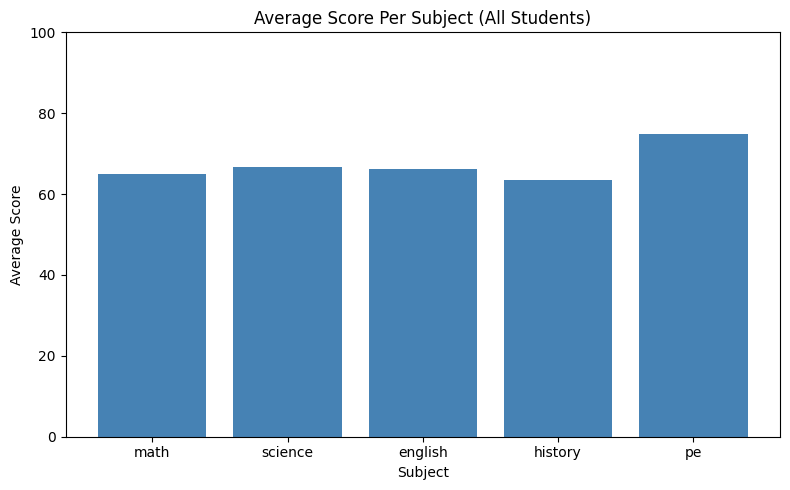

plot1_bar.png saved


In [9]:
# --- Plot 1: Bar Chart ---
# we want one bar per subject showing the average score of all 15 students

subject_means = df[subject_cols].mean()  # mean of each subject column

plt.figure(figsize=(8, 5))
plt.bar(subject_means.index, subject_means.values, color='steelblue')
plt.title('Average Score Per Subject (All Students)')
plt.xlabel('Subject')
plt.ylabel('Average Score')
plt.ylim(0, 100)  # scores are out of 100
plt.tight_layout()
plt.savefig('plot1_bar.png')  # save as png for submission
plt.show()
print('plot1_bar.png saved')

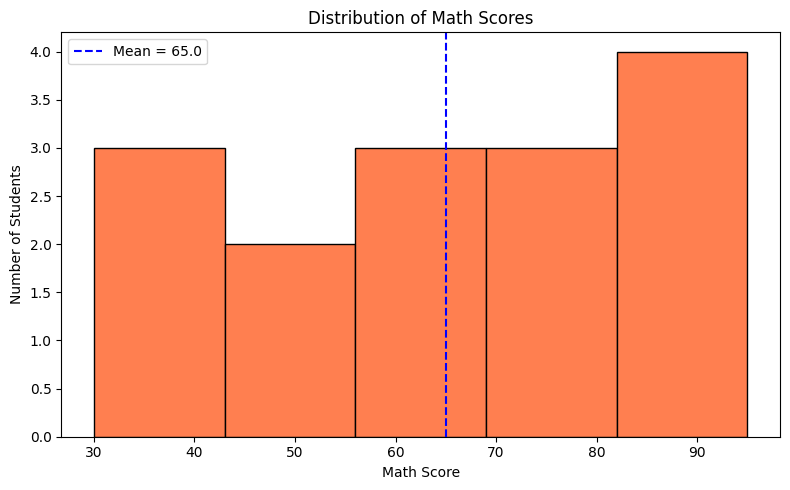

plot2_histogram.png saved


In [10]:
# --- Plot 2: Histogram ---
# shows how math scores are distributed across all students

math_mean = df['math'].mean()  # calculate mean to draw the dashed line

plt.figure(figsize=(8, 5))
plt.hist(df['math'], bins=5, color='coral', edgecolor='black')

# vertical dashed line at the mean score
plt.axvline(math_mean, color='blue', linestyle='--', label=f'Mean = {math_mean:.1f}')
plt.title('Distribution of Math Scores')
plt.xlabel('Math Score')
plt.ylabel('Number of Students')
plt.legend()
plt.tight_layout()
plt.savefig('plot2_histogram.png')
plt.show()
print('plot2_histogram.png saved')

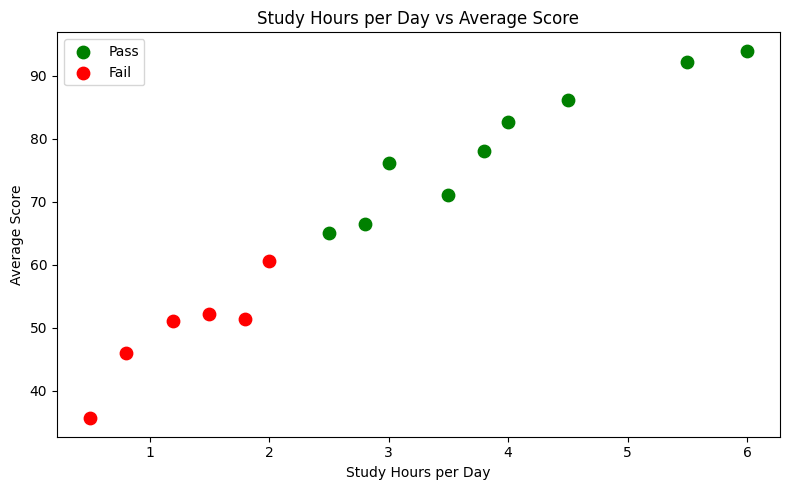

plot3_scatter.png saved


In [11]:
# --- Plot 3: Scatter Plot ---
# x = study hours per day, y = average score
# we plot pass and fail students separately so we can color them differently

pass_students = df[df['passed'] == 1]  # filter only students who passed
fail_students = df[df['passed'] == 0]  # filter only students who failed

plt.figure(figsize=(8, 5))
plt.scatter(pass_students['study_hours_per_day'], pass_students['avg_score'],
            color='green', label='Pass', s=80)
plt.scatter(fail_students['study_hours_per_day'], fail_students['avg_score'],
            color='red', label='Fail', s=80)
plt.title('Study Hours per Day vs Average Score')
plt.xlabel('Study Hours per Day')
plt.ylabel('Average Score')
plt.legend()
plt.tight_layout()
plt.savefig('plot3_scatter.png')
plt.show()
print('plot3_scatter.png saved')

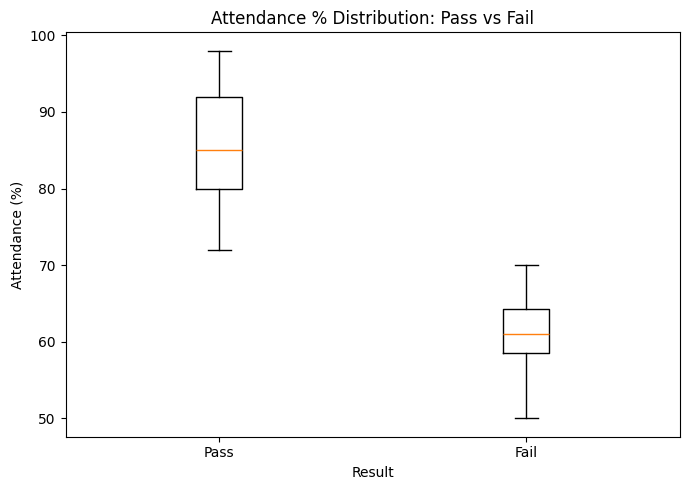

plot4_boxplot.png saved


In [12]:
# --- Plot 4: Box Plot ---
# box plot shows spread of attendance for pass vs fail groups
# we can see if attendance is higher for passing students

pass_attendance = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attendance = df[df['passed'] == 0]['attendance_pct'].tolist()

plt.figure(figsize=(7, 5))
plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])
plt.title('Attendance % Distribution: Pass vs Fail')
plt.xlabel('Result')
plt.ylabel('Attendance (%)')
plt.tight_layout()
plt.savefig('plot4_boxplot.png')
plt.show()
print('plot4_boxplot.png saved')

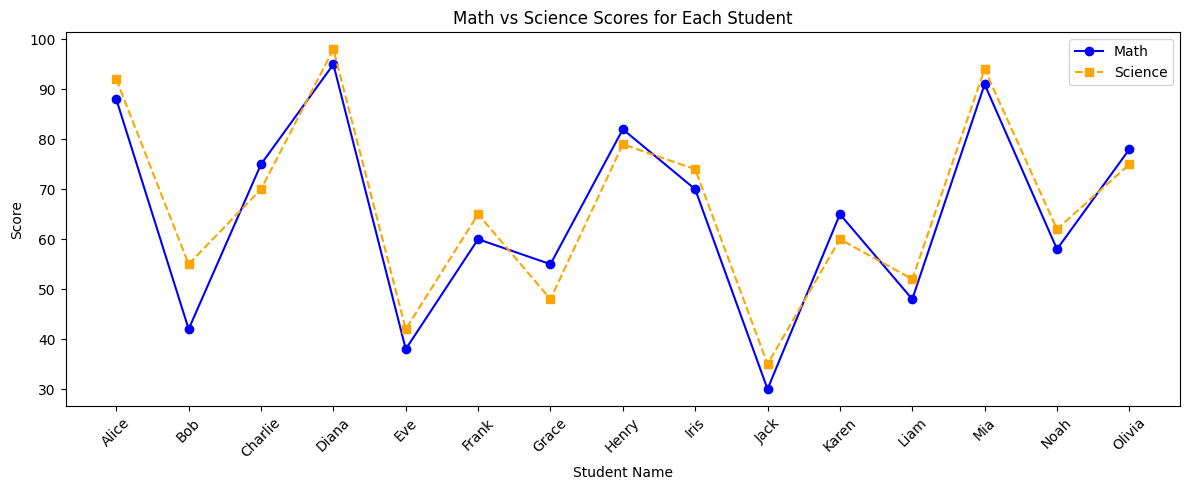

plot5_line.png saved


In [13]:
# --- Plot 5: Line Plot ---
# one line for math scores, another for science scores, for every student
# x-axis = student names, y-axis = score

plt.figure(figsize=(12, 5))
plt.plot(df['name'], df['math'], marker='o', linestyle='-', label='Math', color='blue')
plt.plot(df['name'], df['science'], marker='s', linestyle='--', label='Science', color='orange')
plt.title('Math vs Science Scores for Each Student')
plt.xlabel('Student Name')
plt.ylabel('Score')
plt.xticks(rotation=45)  # rotate names so they don't overlap
plt.legend()
plt.tight_layout()
plt.savefig('plot5_line.png')
plt.show()
print('plot5_line.png saved')

## Task 3 — Data Visualization with Seaborn

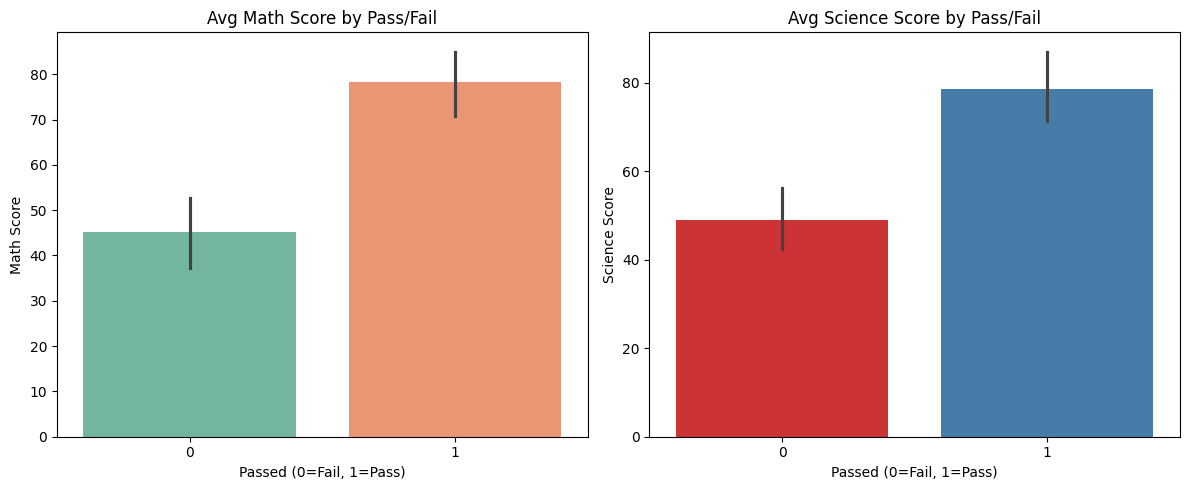

plot6_seaborn_bar.png saved


In [14]:
# --- Plot 6: Seaborn Bar Plot ---
# two subplots side by side - one for math, one for science
# each bar shows the average score split by pass/fail

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# left subplot - average math score for pass vs fail
sns.barplot(data=df, x='passed', y='math', ax=ax1, palette='Set2')
ax1.set_title('Avg Math Score by Pass/Fail')
ax1.set_xlabel('Passed (0=Fail, 1=Pass)')
ax1.set_ylabel('Math Score')

# right subplot - average science score for pass vs fail
sns.barplot(data=df, x='passed', y='science', ax=ax2, palette='Set1')
ax2.set_title('Avg Science Score by Pass/Fail')
ax2.set_xlabel('Passed (0=Fail, 1=Pass)')
ax2.set_ylabel('Science Score')

plt.tight_layout()
plt.savefig('plot6_seaborn_bar.png')
plt.show()
print('plot6_seaborn_bar.png saved')

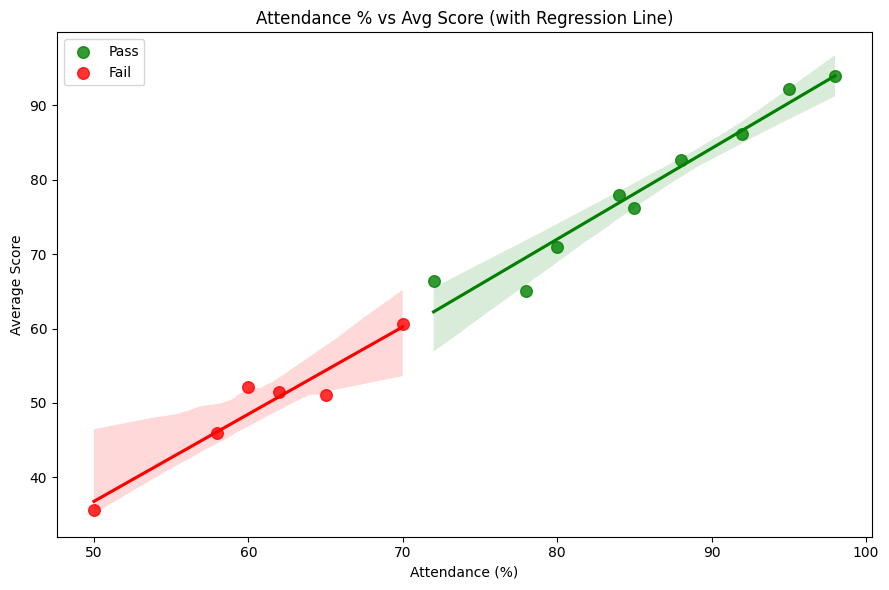

plot7_seaborn_scatter.png saved


In [15]:
# --- Plot 7: Seaborn Scatter + Regression Line ---
# scatter plot of attendance vs avg score, colored by pass/fail
# regplot adds a best fit line to show the trend for each group

plt.figure(figsize=(9, 6))

# regression line + scatter for passing students
sns.regplot(data=df[df['passed'] == 1], x='attendance_pct', y='avg_score',
            label='Pass', color='green', scatter_kws={'s': 70})

# regression line + scatter for failing students
sns.regplot(data=df[df['passed'] == 0], x='attendance_pct', y='avg_score',
            label='Fail', color='red', scatter_kws={'s': 70})

plt.title('Attendance % vs Avg Score (with Regression Line)')
plt.xlabel('Attendance (%)')
plt.ylabel('Average Score')
plt.legend()
plt.tight_layout()
plt.savefig('plot7_seaborn_scatter.png')
plt.show()
print('plot7_seaborn_scatter.png saved')

# Seaborn vs Matplotlib comparison:
# Seaborn was easier for plots that need grouping and color by category -
# it handles that automatically. Matplotlib needed more manual work like
# filtering dataframe and calling scatter twice. But Matplotlib gave more
# control over small details like exact colors and line styles.

## Task 4 — Machine Learning with scikit-learn

In [16]:
# --- Step 1: Prepare Data ---

# features we use to train the model (not name, not passed)
feature_cols = ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']

X = df[feature_cols]  # input features
y = df['passed']      # target we want to predict

# split into 80% training and 20% testing
# random_state=42 makes sure we get same split every time we run
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training samples: {len(X_train)}, Test samples: {len(X_test)}')

# scale features - logistic regression works better when all features
# are on the same scale (mean=0, std=1)
# we fit scaler only on training data to avoid data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit + transform training data
X_test_scaled  = scaler.transform(X_test)        # only transform test data (no fitting)

Training samples: 12, Test samples: 3


In [17]:
# --- Step 2: Train the Model ---

# logistic regression is a simple classification algorithm
# it predicts probability of pass or fail
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)  # train on scaled training data

# check how well the model learned from training data
train_preds = model.predict(X_train_scaled)
train_acc = accuracy_score(y_train, train_preds)
print(f'Training Accuracy: {train_acc * 100:.2f}%')

Training Accuracy: 100.00%


In [18]:
# --- Step 3: Evaluate the Model ---

# predict on test data (data model has never seen)
test_preds = model.predict(X_test_scaled)
test_acc = accuracy_score(y_test, test_preds)
print(f'Test Accuracy: {test_acc * 100:.2f}%')
print()

# print each test student with actual label, predicted label, and correct/wrong
# X_test keeps original dataframe index, so we can use it to look up names
test_names = df.loc[X_test.index, 'name']

print('=== Predictions for Test Students ===')
for name, actual, predicted in zip(test_names, y_test, test_preds):
    result = 'Pass' if predicted == 1 else 'Fail'
    actual_label = 'Pass' if actual == 1 else 'Fail'
    correct = '✅' if actual == predicted else '❌'
    print(f'{name}: Actual={actual_label}, Predicted={result} {correct}')

Test Accuracy: 100.00%

=== Predictions for Test Students ===
Jack: Actual=Fail, Predicted=Fail ✅
Liam: Actual=Fail, Predicted=Fail ✅
Alice: Actual=Pass, Predicted=Pass ✅


In [19]:
# --- Step 4: Feature Importance (Model Coefficients) ---

# model.coef_[0] gives one coefficient per feature
# positive coeff = pushes toward Pass, negative = pushes toward Fail
coefficients = model.coef_[0]

# pair each feature name with its coefficient
coef_pairs = list(zip(feature_cols, coefficients))

# sort by absolute value - largest impact first
coef_pairs_sorted = sorted(coef_pairs, key=lambda x: abs(x[1]), reverse=True)

print('=== Feature Coefficients (sorted by importance) ===')
for feature, coef in coef_pairs_sorted:
    direction = 'towards Pass' if coef > 0 else 'towards Fail'
    print(f'{feature}: {coef:.4f} ({direction})')

=== Feature Coefficients (sorted by importance) ===
english: 0.8125 (towards Pass)
attendance_pct: 0.5219 (towards Pass)
study_hours_per_day: 0.4844 (towards Pass)
pe: 0.4750 (towards Pass)
math: 0.4379 (towards Pass)
science: 0.3230 (towards Pass)
history: 0.2629 (towards Pass)


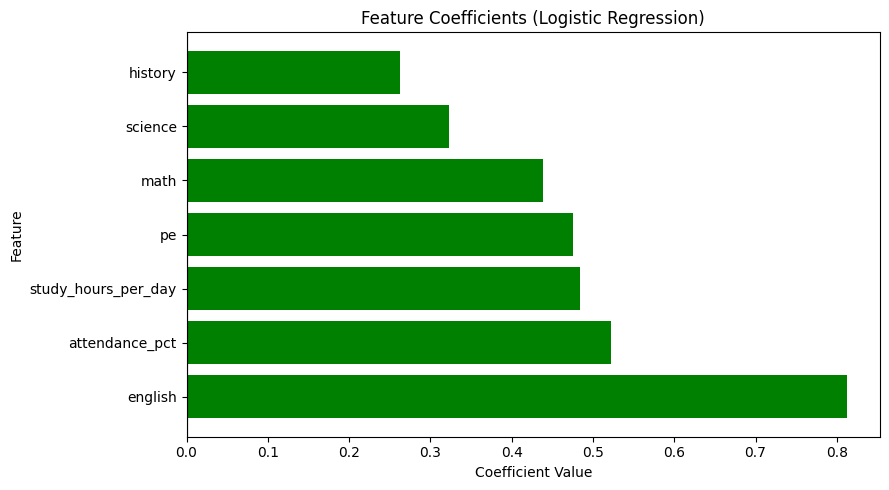

plot8_coefficients.png saved


In [20]:
# --- Feature Coefficient Bar Chart ---
# horizontal bar chart, green for positive coeff, red for negative

features_sorted = [x[0] for x in coef_pairs_sorted]
coefs_sorted    = [x[1] for x in coef_pairs_sorted]

# pick color based on sign of coefficient
colors = ['green' if c > 0 else 'red' for c in coefs_sorted]

plt.figure(figsize=(9, 5))
plt.barh(features_sorted, coefs_sorted, color=colors)
plt.axvline(0, color='black', linewidth=0.8)  # line at zero for reference
plt.title('Feature Coefficients (Logistic Regression)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('plot8_coefficients.png')
plt.show()
print('plot8_coefficients.png saved')

In [21]:
# --- Step 5 (Bonus): Predict for a New Student ---

# made up values for a new student - order must match feature_cols
# [math, science, english, history, pe, attendance_pct, study_hours_per_day]
new_student = [[75, 70, 68, 65, 80, 82, 3.2]]

# scale the new student data using same scaler (already fitted on training data)
new_student_scaled = scaler.transform(new_student)

# predict class (0 or 1)
prediction = model.predict(new_student_scaled)[0]

# predict_proba gives [probability of Fail, probability of Pass]
probabilities = model.predict_proba(new_student_scaled)[0]

result = 'Pass' if prediction == 1 else 'Fail'
print(f'Prediction for new student: {result}')
print(f'Probability of Fail: {probabilities[0]:.2f}')
print(f'Probability of Pass: {probabilities[1]:.2f}')

Prediction for new student: Pass
Probability of Fail: 0.09
Probability of Pass: 0.91
